<a href="https://colab.research.google.com/github/ShaojieDong503/HAD5016-Datathon-4/blob/main/datathon_4_lstm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
IN_DIR = '/content/drive/My Drive/ML_Datathon/Datathon_4'
in_file = "Datathon #4 - mhealth Dataset - HAD7001.csv"

In [ ]:
import os
import re
import io
import numpy as np
import pandas as pd

in_path = os.path.join(IN_DIR, in_file)
df = pd.read_csv(in_path)
df

,alx,aly,alz,glx,gly,glz,arx,ary,arz,grx,gry,grz,Activity,subject
0,2.18490,-9.6967,0.63077,0.103900,-0.84053,-0.68762,-8.6499,-4.5781,0.187760,-0.44902,-1.01030,0.034483,0,subject1
1,2.38760,-9.5080,0.68389,0.085343,-0.83865,-0.68369,-8.6275,-4.3198,0.023595,-0.44902,-1.01030,0.034483,0,subject1
2,2.40860,-9.5674,0.68113,0.085343,-0.83865,-0.68369,-8.5055,-4.2772,0.275720,-0.44902,-1.01030,0.034483,0,subject1
3,2.18140,-9.4301,0.55031,0.085343,-0.83865,-0.68369,-8.6279,-4.3163,0.367520,-0.45686,-1.00820,0.025862,0,subject1
4,2.41730,-9.3889,0.71098,0.085343,-0.83865,-0.68369,-8.7008,-4.1459,0.407290,-0.45686,-1.00820,0.025862,0,subject1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999994,0.75593,-8.9661,4.38220,-0.465680,-0.54597,0.61690,-6.6138,-2.5801,6.985600,-0.69804,0.48049,0.616380,2,subject9
999995,0.76348,-8.8288,4.25370,-0.465680,-0.54597,0.61690,-6.4246,-2.5633,6.673900,-0.69804,0.48049,0.616380,2,subject9
999996,0.76376,-8.9685,4.14250,-0.484230,-0.54221,0.63065,-6.8242,-2.5435,6.654100,-0.71373,0.46817,0.601290,2,subject9
999997,0.80362,-8.8894,4.12610,-0.484230,-0.54221,0.63065,-6.6379,-2.5223,6.769700,-0.71373,0.46817,0.601290,2,subject9


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# -------------------------
# Basic inspection
# -------------------------
print("Shape:", df.shape)
print(df.head())
print(df.dtypes)
print(df.isna().sum())



Shape: (999999, 14)
      alx     aly      alz       glx      gly      glz     arx     ary  \
0  2.1849 -9.6967  0.63077  0.103900 -0.84053 -0.68762 -8.6499 -4.5781   
1  2.3876 -9.5080  0.68389  0.085343 -0.83865 -0.68369 -8.6275 -4.3198   
2  2.4086 -9.5674  0.68113  0.085343 -0.83865 -0.68369 -8.5055 -4.2772   
3  2.1814 -9.4301  0.55031  0.085343 -0.83865 -0.68369 -8.6279 -4.3163   
4  2.4173 -9.3889  0.71098  0.085343 -0.83865 -0.68369 -8.7008 -4.1459   

        arz      grx     gry       grz  Activity   subject  
0  0.187760 -0.44902 -1.0103  0.034483         0  subject1  
1  0.023595 -0.44902 -1.0103  0.034483         0  subject1  
2  0.275720 -0.44902 -1.0103  0.034483         0  subject1  
3  0.367520 -0.45686 -1.0082  0.025862         0  subject1  
4  0.407290 -0.45686 -1.0082  0.025862         0  subject1  
alx         float64
aly         float64
alz         float64
glx         float64
gly         float64
glz         float64
arx         float64
ary         float64
arz      

In [ ]:
# =========================================================
# 0. IMPORTS
# =========================================================
import numpy as np
import pandas as pd
from collections import Counter

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import matplotlib.pyplot as plt

In [ ]:
# =========================================================
# 1. CONFIG
# =========================================================
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

feature_cols = [
    "alx", "aly", "alz",
    "glx", "gly", "glz",
    "arx", "ary", "arz",
    "grx", "gry", "grz"
]

target_col = "Activity"
subject_col = "subject"

WINDOW_SIZE = 128
STEP_SIZE = 64
MIN_MAJORITY_FRAC = 0.8

val_subjects = ["subject7"]
test_subjects = ["subject8", "subject9"]

BATCH_SIZE = 128
NUM_EPOCHS = 20
PATIENCE = 5
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 0.0

Using device: cpu


In [ ]:
# =========================================================
# 3. CLEAN DATA
# =========================================================
df = df.loc[:, ~df.columns.astype(str).str.contains("^Unnamed")]
df.columns = [str(c).strip() for c in df.columns]

required_cols = feature_cols + [target_col, subject_col]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

df = df[required_cols].copy()

for c in feature_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df[target_col] = pd.to_numeric(df[target_col], errors="coerce")
df[subject_col] = df[subject_col].astype(str).str.strip()

df = df.dropna(subset=feature_cols + [target_col, subject_col]).copy()
df = df.drop_duplicates().copy()

df = df.reset_index(drop=False).rename(columns={"index": "orig_idx"})
df = df.sort_values([subject_col, "orig_idx"]).reset_index(drop=True)

print("Cleaned shape:", df.shape)
print("\nRows per subject:")
print(df[subject_col].value_counts().sort_index())

print("\nRaw class counts:")
print(df[target_col].value_counts().sort_index())

Cleaned shape: (999999, 15)

Rows per subject:
subject
subject1    161280
subject2    130561
subject3    122112
subject4    116736
subject5    119808
subject6     98304
subject7    104448
subject8    129024
subject9     17726
Name: count, dtype: int64

Raw class counts:
Activity
0     720946
1      27648
2      25406
3      24576
4      24576
5      24576
6      22990
7      23809
8      23501
9      24576
10     24576
11     24576
12      8243
Name: count, dtype: int64


In [ ]:
# =========================================================
# 4. SUBJECT-WISE SPLIT
# =========================================================
all_subjects = sorted(df[subject_col].unique())
train_subjects = [s for s in all_subjects if s not in val_subjects + test_subjects]

train_df = df[df[subject_col].isin(train_subjects)].copy()
val_df   = df[df[subject_col].isin(val_subjects)].copy()
test_df  = df[df[subject_col].isin(test_subjects)].copy()





print("Train subjects:", train_subjects)
print("Val subjects:", val_subjects)
print("Test subjects:", test_subjects)

print("Train rows:", train_df.shape)
print("Val rows:", val_df.shape)
print("Test rows:", test_df.shape)

Train subjects: ['subject1', 'subject2', 'subject3', 'subject4', 'subject5', 'subject6']
Val subjects: ['subject7']
Test subjects: ['subject8', 'subject9']
Train rows: (748801, 15)
Val rows: (104448, 15)
Test rows: (146750, 15)


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
val_df[feature_cols]   = scaler.transform(val_df[feature_cols])
test_df[feature_cols]  = scaler.transform(test_df[feature_cols])

In [ ]:
# =========================================================
# 5. WINDOWING
#    - majority label
#    - drop ambiguous windows
#    - no normalization
# =========================================================
def create_windows_majority(
    df_in,
    feature_cols,
    target_col="Activity",
    subject_col="subject",
    window_size=128,
    step_size=64,
    min_majority_frac=0.8
):
    X_list = []
    y_list = []
    meta_list = []

    for subj, g in df_in.groupby(subject_col, sort=False):
        g = g.sort_values("orig_idx").reset_index(drop=True)

        X_subj = g[feature_cols].to_numpy(dtype=np.float32)
        y_subj = g[target_col].to_numpy(dtype=np.int64)

        n = len(g)
        if n < window_size:
            continue

        for start in range(0, n - window_size + 1, step_size):
            end = start + window_size
            x_win = X_subj[start:end]
            y_win = y_subj[start:end]

            vals, counts = np.unique(y_win, return_counts=True)
            maj_idx = np.argmax(counts)
            maj_class = vals[maj_idx]
            maj_frac = counts[maj_idx] / window_size

            if maj_frac < min_majority_frac:
                continue

            X_list.append(x_win)
            y_list.append(maj_class)
            meta_list.append({
                "subject": subj,
                "start_idx": start,
                "end_idx": end - 1,
                "majority_frac": maj_frac,
                "label": maj_class
            })

    X = np.stack(X_list).astype(np.float32)
    y = np.array(y_list, dtype=np.int64)
    meta = pd.DataFrame(meta_list)
    return X, y, meta

In [ ]:
# =========================================================
# 6. BUILD TRAIN / VAL / TEST WINDOWS
# =========================================================
X_train, y_train, meta_train = create_windows_majority(
    train_df,
    feature_cols=feature_cols,
    target_col=target_col,
    subject_col=subject_col,
    window_size=WINDOW_SIZE,
    step_size=STEP_SIZE,
    min_majority_frac=MIN_MAJORITY_FRAC
)

X_val, y_val, meta_val = create_windows_majority(
    val_df,
    feature_cols=feature_cols,
    target_col=target_col,
    subject_col=subject_col,
    window_size=WINDOW_SIZE,
    step_size=STEP_SIZE,
    min_majority_frac=MIN_MAJORITY_FRAC
)

X_test, y_test, meta_test = create_windows_majority(
    test_df,
    feature_cols=feature_cols,
    target_col=target_col,
    subject_col=subject_col,
    window_size=WINDOW_SIZE,
    step_size=STEP_SIZE,
    min_majority_frac=MIN_MAJORITY_FRAC
)

print("Train windows:", X_train.shape, Counter(y_train))
print("Val windows:  ", X_val.shape, Counter(y_val))
print("Test windows: ", X_test.shape, Counter(y_test))

Train windows: (11539, 128, 12) Counter({np.int64(0): 8372, np.int64(1): 282, np.int64(2): 282, np.int64(3): 282, np.int64(4): 282, np.int64(9): 282, np.int64(10): 282, np.int64(11): 282, np.int64(5): 282, np.int64(7): 276, np.int64(8): 276, np.int64(6): 269, np.int64(12): 90})
Val windows:   (1595, 128, 12) Counter({np.int64(0): 1078, np.int64(1): 47, np.int64(2): 47, np.int64(3): 47, np.int64(4): 47, np.int64(6): 47, np.int64(9): 47, np.int64(10): 47, np.int64(11): 47, np.int64(8): 43, np.int64(7): 42, np.int64(5): 41, np.int64(12): 15})
Test windows:  (2260, 128, 12) Counter({np.int64(0): 1694, np.int64(1): 94, np.int64(2): 58, np.int64(3): 47, np.int64(4): 47, np.int64(9): 47, np.int64(10): 47, np.int64(11): 47, np.int64(5): 46, np.int64(7): 46, np.int64(8): 39, np.int64(6): 33, np.int64(12): 15})


In [ ]:
# =========================================================
# 7. DATASET
# =========================================================
class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = SequenceDataset(X_train, y_train)
val_dataset   = SequenceDataset(X_val, y_val)
test_dataset  = SequenceDataset(X_test, y_test)

In [ ]:

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,

)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [ ]:
# =========================================================
# 9. NORMAL LSTM
# =========================================================
num_classes = len(np.unique(y_train))
timesteps = X_train.shape[1]
n_features = X_train.shape[2]

print("num_classes:", num_classes)
print("timesteps:", timesteps)
print("n_features:", n_features)

class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1, num_classes=3, dropout=0.2):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.0  # no dropout inside LSTM for 1 layer
        )

        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # x: (B, T, F)
        out, (hn, cn) = self.lstm(x)
        last_hidden = hn[-1]   # (B, hidden_size)
        logits = self.fc(last_hidden)
        return logits

model = LSTMClassifier(
    input_size=n_features,
    hidden_size=64,
    num_layers=1,
    num_classes=num_classes,
    dropout=0.2
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print(model)

num_classes: 13
timesteps: 128
n_features: 12
LSTMClassifier(
  (lstm): LSTM(12, 64, batch_first=True)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=13, bias=True)
  )
)


In [ ]:
# =========================================================
# 10. TRAIN / EVAL FUNCTIONS
# =========================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(y_batch.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            running_loss += loss.item() * X_batch.size(0)

            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc, np.array(all_labels), np.array(all_preds)

In [ ]:
# =========================================================
# 11. TRAIN LOOP
# =========================================================
def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=20, patience=5):
    best_val_loss = float("inf")
    best_state = None
    patience_counter = 0

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch+1:02d}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history

In [ ]:
# =========================================================
# 12. TRAIN
# =========================================================
model, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE
)

Epoch 01/20 | Train Loss: 1.5943 | Train Acc: 0.6653 | Val Loss: 1.3567 | Val Acc: 0.6759
Epoch 02/20 | Train Loss: 1.1878 | Train Acc: 0.7373 | Val Loss: 1.2906 | Val Acc: 0.6759
Epoch 03/20 | Train Loss: 1.1057 | Train Acc: 0.7406 | Val Loss: 1.2241 | Val Acc: 0.6759
Epoch 04/20 | Train Loss: 1.0166 | Train Acc: 0.7466 | Val Loss: 1.1077 | Val Acc: 0.6940
Epoch 05/20 | Train Loss: 0.9321 | Train Acc: 0.7535 | Val Loss: 1.0996 | Val Acc: 0.6909
Epoch 06/20 | Train Loss: 0.9014 | Train Acc: 0.7524 | Val Loss: 1.1057 | Val Acc: 0.6915
Epoch 07/20 | Train Loss: 0.8646 | Train Acc: 0.7505 | Val Loss: 1.0386 | Val Acc: 0.7047
Epoch 08/20 | Train Loss: 0.8121 | Train Acc: 0.7580 | Val Loss: 1.0082 | Val Acc: 0.6928
Epoch 09/20 | Train Loss: 0.7726 | Train Acc: 0.7565 | Val Loss: 0.9811 | Val Acc: 0.7166
Epoch 10/20 | Train Loss: 0.7530 | Train Acc: 0.7666 | Val Loss: 0.9666 | Val Acc: 0.7160
Epoch 11/20 | Train Loss: 0.7314 | Train Acc: 0.7636 | Val Loss: 0.9684 | Val Acc: 0.7248
Epoch 12/2

In [ ]:
# =========================================================
# 13. FINAL EVALUATION
# =========================================================
train_loss, train_acc, y_train_true, y_train_pred = evaluate(model, train_loader, criterion, device)
val_loss, val_acc, y_val_true, y_val_pred = evaluate(model, val_loader, criterion, device)
test_loss, test_acc, y_test_true, y_test_pred = evaluate(model, test_loader, criterion, device)

print("\nFinal metrics")
print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
print(f"Test  Loss: {test_loss:.4f} | Test  Acc: {test_acc:.4f}")


Final metrics
Train Loss: 0.5211 | Train Acc: 0.8037
Val   Loss: 0.7800 | Val   Acc: 0.7285
Test  Loss: 0.7664 | Test  Acc: 0.7699


In [ ]:
# =========================================================
# 14. REPORTS
# =========================================================
print("\nTEST CLASSIFICATION REPORT")
print(classification_report(y_test_true, y_test_pred, digits=4))

print("TEST CONFUSION MATRIX")
print(confusion_matrix(y_test_true, y_test_pred))


TEST CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.7887    0.9498    0.8618      1694
           1     0.0000    0.0000    0.0000        94
           2     0.0000    0.0000    0.0000        58
           3     0.0000    0.0000    0.0000        47
           4     0.0000    0.0000    0.0000        47
           5     0.0000    0.0000    0.0000        46
           6     0.0000    0.0000    0.0000        33
           7     0.0000    0.0000    0.0000        46
           8     0.5405    0.5128    0.5263        39
           9     0.3443    0.4468    0.3889        47
          10     0.7174    0.7021    0.7097        47
          11     0.8393    1.0000    0.9126        47
          12     0.6667    0.6667    0.6667        15

    accuracy                         0.7699      2260
   macro avg     0.2998    0.3291    0.3128      2260
weighted avg     0.6445    0.7699    0.7013      2260

TEST CONFUSION MATRIX
[[1609    0    0    0    5   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


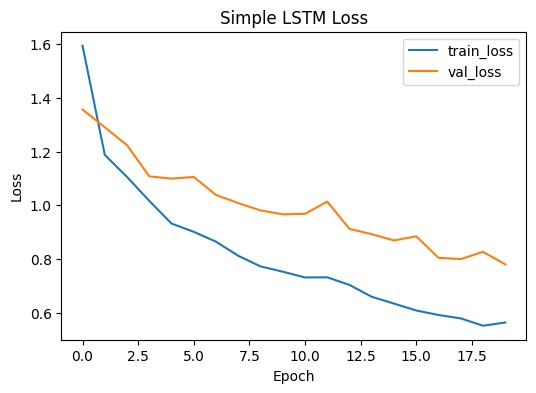

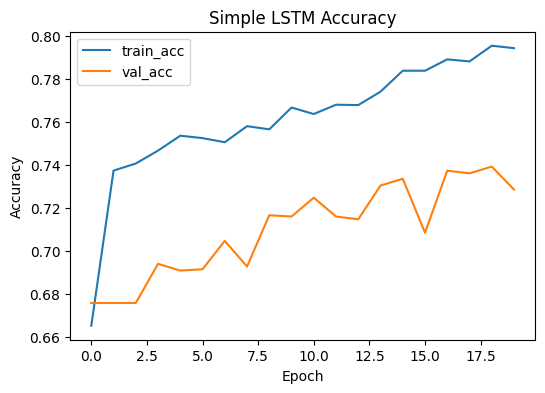

In [ ]:
# =========================================================
# 15. PLOT HISTORY
# =========================================================
def plot_history(history, title="LSTM"):
    plt.figure(figsize=(6, 4))
    plt.plot(history["train_loss"], label="train_loss")
    plt.plot(history["val_loss"], label="val_loss")
    plt.title(f"{title} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(history["train_acc"], label="train_acc")
    plt.plot(history["val_acc"], label="val_acc")
    plt.title(f"{title} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

plot_history(history, title="Simple LSTM")